## Oxford Nanopore DNA sequencing of four bacterial strains  

ERASMUS Blended Intensive Program (BIP): "Advanced biological analyses using microfluidics"  
**Hands-on Bioinformatics Tutorial**
- Todd Blevins — CNRS group leader (IBMP)
- Calvin Matteoli — bioinformatician (ETH Zurich)

---

In this session we work with **Oxford Nanopore R10.4.1 DNA sequencing** data. Four bacterial
strains were prepared together, barcoded, and sequenced on a single MinION flow cell:

| Strain | Description |
|---|---|
| *Lacticaseibacillus casei* | a lactic-acid bacterium (yoghurt / probiotics) |
| *Bacillus subtilis* | a soil bacterium that forms spores |
| *Escherichia coli* DH5&alpha; | the harmless, familiar lab cloning strain of *E. coli*|
| *Escherichia coli* O157:H7 | avirulent strain (*stx1* and *stx2* negative) of an otherwise pathogenic *E. coli*|

The aim of this tutorial is to take the MinION sequencer output and, step by step:

1. look at the **raw signal** (in pod5 format) and the **basecalling** that turns it into human-readable DNA sequences,
2. **demultiplex** - sort the mixed reads back into the four strains by their barcode,
3. **quality-control** the reads,
4. **map** each strain's reads to a reference genome, and
5. **compare** the four genomes - ending with a neat trick: reading the number of
   **ribosomal RNA (rrn) operons** straight off the sequencing depth.

### Background: the ribosomal RNA (rrn) operon

A recurring gene model in this tutorial is the bacterial **rrn operon**. The genes for the
ribosomal RNAs (**16S, 23S, 5S**) are transcribed together as one ~5 kb unit, with one or more
**tRNA** genes in the internal spacer. Bacteria carry **several copies** of this operon
(fast growers more, slow growers fewer); at the end of the tutorial we **count those copies
straight from sequencing depth**.

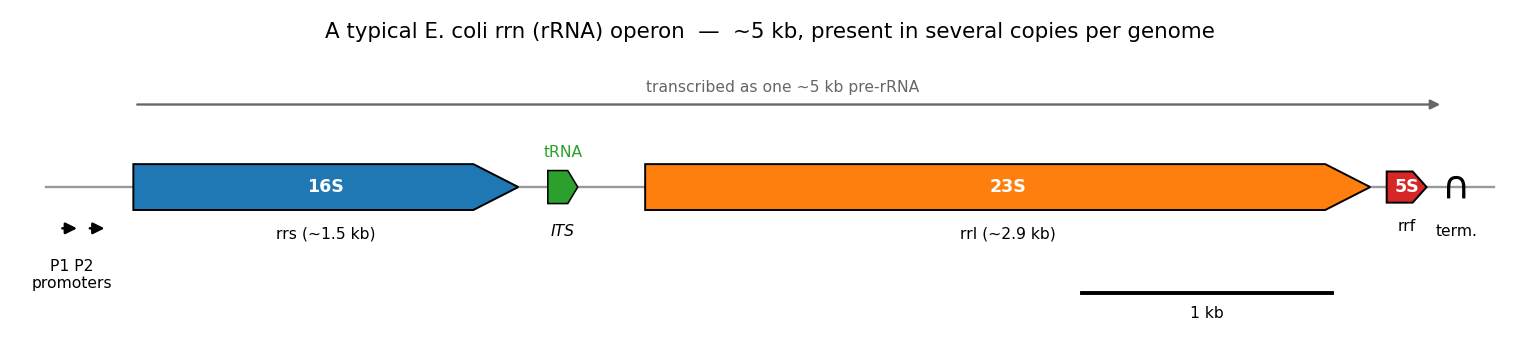

In [84]:
# A typical E. coli rrn operon (schematic)
from IPython.display import Image
Image("analysis/rrn_operon_diagram.png")

> *To start this tutorial, do the following steps (once):*
>
> This training can be downloaded at https://github.com/toddblev/bacto-ont
> Your working directory will be where you saved the github repo.
>
> **1. Navigate to the tutorial directory**
> ```bash
> cd bacto-ont
> ```
> **2. Create the tutorial environment**
> ```bash
> conda env create -f environment.yml
> ```
> **3. Activate the environment**
> ```bash
> conda activate bip
> ```
> **4. Start Jupyter and open the tutorial**
> ```bash
> jupyter lab bacto_ont.ipynb
> ```

In [85]:
# Check that the conda environment is active and the tools are available
! python --version
! samtools --version | head -1
! minimap2 --version
! NanoPlot --version
! fastplong --version 2>&1 | head -1
! mosdepth --version

Python 3.13.14
samtools 1.23
2.31-r1302
NanoPlot 1.47.1
fastplong 0.4.1
mosdepth 0.3.13


In [86]:
# ================================================================
#  DOWNLOAD the tutorial data (one ~580 MB tarball) from the GitHub Release
# ----------------------------------------------------------------
#  Contains: the pod5 subsample, the per-barcode reads (raw + cleaned),
#  and the four reference genomes. Re-running is safe (skips if present).
# ================================================================
import os, hashlib, urllib.request, tarfile

DATA = {
    "url": "https://github.com/toddblev/bacto-ont/releases/download/v1.0/bacto_ont_data.tar.gz",
    "md5": "9bb9572a4ec6c5dfd2295049f5199c80",
    "marker": "pod5/bacto_subsample.pod5",   # a file that exists once extracted
}

def _md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def fetch_data(meta, tarball="bacto_ont_data.tar.gz"):
    if os.path.exists(meta["marker"]):
        print(f"\u2713 data already present ({meta['marker']})")
        return
    print("\u2193 downloading tutorial data (~580 MB) ...")
    urllib.request.urlretrieve(meta["url"], tarball)
    if meta["md5"] and _md5(tarball) != meta["md5"]:
        raise ValueError("checksum mismatch \u2014 download may be corrupt; re-run this cell")
    print("extracting ...")
    with tarfile.open(tarball) as t:
        t.extractall(".")
    os.remove(tarball)
    print("\u2713 data ready")

fetch_data(DATA)

✓ data already present (pod5/bacto_subsample.pod5)


In [87]:
! tree -L 2 . 2>/dev/null || ls -F

.
├── analysis
│   ├── coverage_ecoli_K12.png
│   ├── coverage_track.py
│   ├── cross_mapping_matrix_clean.png
│   ├── cross_mapping_matrix_raw.png
│   ├── cross_mapping_matrix.py
│   ├── demux_read_counts.png
│   ├── extract_rrn_operon.py
│   ├── rrn_copy_number.png
│   ├── rrn_copy_number.py
│   ├── rrn_operon_diagram.png
│   ├── rrn_operon_diagram.py
│   └── squiggle.png
├── assembly
│   ├── dh5a_assembly_info.txt
│   └── dh5a_assembly.fasta
├── bacto_ont.ipynb
├── basecalls
│   └── calls_demo.bam
├── cheatsheets
│   ├── conda_cheatsheet.pdf
│   ├── git_cheatsheet.pdf
│   ├── python_reference_pcc.pdf
│   ├── python_reference_rp.pdf
│   └── unix_linux_commands.pdf
├── CLAUDE.md
├── environment.yml
├── LICENSE
├── mapping_bam
│   ├── bsubtilis.bam
│   ├── bsubtilis.bam.bai
│   ├── ecoli_K12.bam
│   ├── ecoli_K12.bam.bai
│   ├── ecoli_O157.bam
│   ├── ecoli_O157.bam.bai
│   ├── lcasei.bam
│   └── lcasei.bam.bai
├── pod5
│   └── bacto_subsample.pod5
├── qc
│   ├── barcode01.fastplong.ht

### Oxford Nanopore sequencing file formats

A Nanopore run moves through several file formats. The sequencer records the raw electrical
**signal** in **pod5** files - the current format for both **DNA (R10.4.1)** and RNA flow
cells, replacing the older **fast5**. **Basecalling** then turns that signal into reads, which
Dorado writes as **BAM** (here BAM stores the basecalled reads *before* any mapping, and can
also carry DNA **modification** calls). For most tools we convert reads to **FASTQ**. The run
also emits plain-**text** summaries/logs.

| Format | Role |
|---|---|
| `pod5` | raw-signal format for DNA (R10.4.1) and RNA flow cells |
| `fast5` | legacy raw-signal format (older R9.4.1 chemistry) - deprecated |
| `BAM` | basecalled reads (even before mapping); can include modification info; also the alignment format |
| `FASTQ` | standard read format (sequence + quality); cannot store modification info |
| `text` | summaries and logs (e.g. `sequencing_summary.txt`) |

### Tools for working with bioinformatics files

> Do **not** use Microsoft Word to view or edit sequence, mapping or annotation files
> (FASTA, FASTQ, GFF3, SAM...), tables (CSV/TSV) or scripts. Word alters plain text and can
> corrupt these files, and large files crash Word/Excel.

| Category | Recommendation | Notes |
|---|---|---|
| Editor | [VS Code](https://code.visualstudio.com/download) | best general-purpose choice for text-based bioinformatics files |
| Terminal | macOS [iTerm2](https://iterm2.com), Linux terminal, WSL, PowerShell | where you inspect files and run tools |
| Notebook | Jupyter | **this file** - great for exploring data and documenting analyses |

### The experiment in one file: `samples.tsv`

Everything about the four samples is recorded in a small table, a text file in tab-delimited format,
`samples.tsv`, including:  
1. **barcode** that was used in the library preparation for each strain (derived from the [SQK-RBK114-24 "Rapid Barcoding" kit](https://store.nanoporetech.com/eu/rapid-barcoding-sequencing-kit-24-v14.html))
2. **reference genome** to which we can map the Oxford Nanopore data
3. **rrn operon** reference extracted from each strain, used at the end of the tutorial
4. **Number of rrn operons** in each genome (= the "answer" we will try to recover from the data).


In [88]:
import pandas as pd
samples = pd.read_csv("samples.tsv", sep="\t")
samples

,barcode,key,strain,reference,operon,rrn_copies
0,barcode01,bsubtilis,Bacillus subtilis 168,reference_seqs/ref_bsubtilis_168.fna,reference_seqs/operons/bsubtilis_rrn_operon.fna,10
1,barcode02,ecoli_O157,Escherichia coli O157:H7 Sakai,reference_seqs/ref_ecoli_O157_Sakai.fna,reference_seqs/operons/ecoli_O157_rrn_operon.fna,7
2,barcode03,lcasei,Lacticaseibacillus casei ATCC 393,reference_seqs/ref_lcasei_ATCC393.fna,reference_seqs/operons/lcasei_rrn_operon.fna,5
3,barcode04,ecoli_K12,Escherichia coli DH5alpha (K-12),reference_seqs/ref_ecoli_K12_MG1655.fna,reference_seqs/operons/ecoli_K12_rrn_operon.fna,7


### Project directory layout

### Inspecting the raw signal (pod5)

The full run is dozens of large pod5 files (many GB). For this tutorial we use a small random
**subsample**, `pod5/bacto_subsample.pod5` (10,000 reads).   
**pod5 files** are not text files and thus cannot be opened in a text editor; we use the python `pod5` library tool to look inside.

In [89]:
! pod5 inspect summary pod5/bacto_subsample.pod5

Originating file version 0.3.39, in memory read table version 4.
File version on disk 0.3.39.
File uses VBZ compression.
Batch 1, 1000 reads
Batch 2, 1000 reads
Batch 3, 1000 reads
Batch 4, 1000 reads
Batch 5, 1000 reads
Batch 6, 1000 reads
Batch 7, 1000 reads
Batch 8, 1000 reads
Batch 9, 1000 reads
Batch 10, 1000 reads
Found 10 batches, 10000 reads


In [90]:
# the per-read metadata table (channel = pore, num_samples = signal length, sample_rate = Hz)
! pod5 view pod5/bacto_subsample.pod5 | head

read_id	filename	read_number	channel	mux	end_reason	start_time	start_sample	duration	num_samples	minknow_events	sample_rate	median_before	predicted_scaling_scale	predicted_scaling_shift	tracked_scaling_scale	tracked_scaling_shift	num_reads_since_mux_change	time_since_mux_change	run_id	sample_id	experiment_id	flow_cell_id	pore_type	open_pore_level
8bdf8241-03b2-4668-a2ea-2d7b16392d92	bacto_subsample.pod5	9	390	4	signal_positive	2724.26680000	13621334	9.92580000	49629	5832	5000	190.32186890	0.00000000	0.00000000	0.00000000	0.00000000	0	0.00000000	e9e97897-3865-4a54-8f92-5c4515fc39c7	not_set	093_BIP_rapid_test	FAW56562	not_set	NaN
6d344c52-bd46-4669-9eba-6fe4166200ae	bacto_subsample.pod5	86	402	4	signal_positive	2722.94180000	13614709	23.57320000	117866	12891	5000	196.85742188	0.00000000	0.00000000	0.00000000	0.00000000	0	0.00000000	e9e97897-3865-4a54-8f92-5c4515fc39c7	not_set	093_BIP_rapid_test	FAW56562	not_set	NaN
6a93c5f4-7d91-45de-850f-e23fb8d75486	bacto_subsample.pod5	118	414	4	unblo

In [91]:
# Open the file in Python, take the first read, and print info from the raw data.
# Note: R10.4.1 DNA runs sample at 5 kHz and translocate DNA at ~400 bases/second.
import pod5

with pod5.Reader("pod5/bacto_subsample.pod5") as reader:
    read = next(reader.reads())
    sr = read.run_info.sample_rate
    print("read_id      :", read.read_id)
    print("flow cell    :", read.run_info.flow_cell_id)
    print("pore channel :", read.pore.channel)
    print("sample rate  :", sr, "Hz")
    print("num samples  :", read.num_samples, "signal points")
    print("duration     :", round(read.num_samples / sr, 3), "seconds")
    print("raw signal   :", read.signal[:10], "...")

read_id      : 8bdf8241-03b2-4668-a2ea-2d7b16392d92
flow cell    : FAW56562
pore channel : 390
sample rate  : 5000 Hz
num samples  : 49629 signal points
duration     : 9.926 seconds
raw signal   : [466 475 509 471 484 505 513 522 496 515] ...


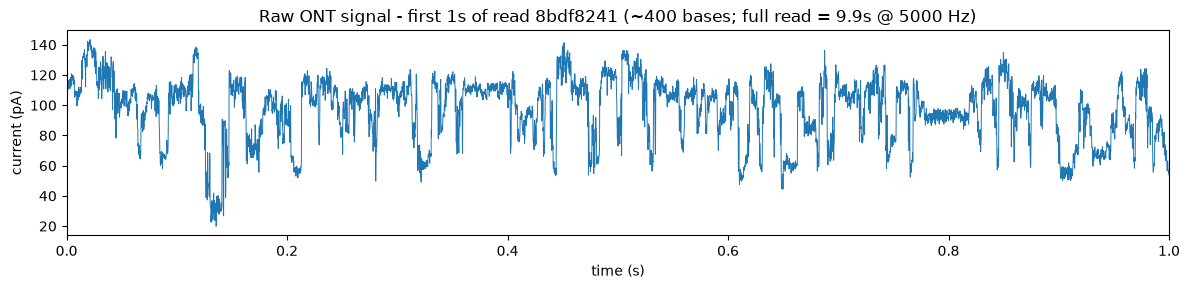

In [92]:
# Plot one read's raw signal - the ONT "squiggle". The basecaller's job is to read
# the DNA sequence out of wiggles like these.
# A full read is many seconds long; at ~400 bases/s and 5 kHz that is ~12 samples per base,
# so we zoom into a 1-second window (~400 bases) to actually see the signal stepping.
import matplotlib.pyplot as plt
import numpy as np
import pod5

WINDOW_S = 1.0
with pod5.Reader("pod5/bacto_subsample.pod5") as reader:
    read = next(reader.reads())
    current_pa = read.signal_pa            # calibrated current in picoamps
    sr = read.run_info.sample_rate
    rid = str(read.read_id)

n = int(WINDOW_S * sr)
s = current_pa[:n]
t = np.arange(len(s)) / sr
plt.figure(figsize=(12, 3))
plt.plot(t, s, lw=0.7)
plt.xlim(0, WINDOW_S)
plt.xlabel("time (s)"); plt.ylabel("current (pA)")
plt.title(f"Raw ONT signal - first {WINDOW_S:g}s of read {rid[:8]} "
          f"(~{int(WINDOW_S*400)} bases; full read = {len(current_pa)/sr:.1f}s @ {sr} Hz)")
plt.tight_layout(); plt.savefig("analysis/squiggle.png", dpi=130); plt.show()

### Basecalling: Dorado and its accuracy models

[Dorado](https://software-docs.nanoporetech.com/dorado/latest/) turns the raw signal into DNA
sequence. It offers three accuracy levels - **fast**, **hac** (high accuracy) and **sup**
(super accuracy) - trading speed for accuracy. Basecalling needs an NVIDIA GPU and takes a
while, so **we did it for you ahead of time**; this section just shows the results.

| Level | Model (R10.4.1 DNA) | Speed | Accuracy |
|---|---|---|---|
| fast | `dna_r10.4.1_e8.2_400bps_fast` | fastest | lowest |
| hac  | `dna_r10.4.1_e8.2_400bps_hac`  | medium  | high |
| sup  | `dna_r10.4.1_e8.2_400bps_sup`  | slowest | highest |


We basecalled the same 20,000 reads with each model and compared them with **NanoComp**.

In [93]:
# Summary statistics for the three models (generated offline with NanoComp)
! sed -n '1,20p' qc/model_compare/models_NanoStats.txt

General summary:                   fast            hac            sup
Active channels:                  175.0          175.0          175.0
Mean read length:               2,167.9        2,198.0        2,211.5
Mean read quality:                  5.6            7.0            7.2
Median read length:               500.0          493.0          499.0
Median read quality:                6.2            8.3            8.7
Number of reads:               20,148.0       20,175.0       20,206.0
Read length N50:                8,292.0        8,507.0        8,601.0
STDEV read length:              4,457.2        4,542.3        4,557.7
Total bases:               43,679,408.0   44,344,176.0   44,684,585.0
Number, percentage and megabases of reads above quality cutoffs
>Q10:	1788 (8.9%) 5.6Mb	7887 (39.1%) 22.6Mb	8889 (44.0%) 24.3Mb
>Q15:	7 (0.0%) 0.0Mb	3349 (16.6%) 12.4Mb	5271 (26.1%) 17.2Mb
>Q20:	3 (0.0%) 0.0Mb	359 (1.8%) 0.7Mb	1861 (9.2%) 6.5Mb
>Q25:	1 (0.0%) 0.0Mb	21 (0.1%) 0.0Mb	273 (1.4%) 0.3Mb
>

In [94]:
# Interactive quality comparison (fast -> hac -> sup), rendered inline
from IPython.display import IFrame
IFrame("qc/model_compare/models_NanoComp_quals_violin.html", width="100%", height=600)

Quality improves **fast &rarr; hac &rarr; sup**, as expected. R10.4.1 DNA is high quality:
even hac is very good, and sup adds the extra accuracy that matters for fine analyses. For the
rest of the tutorial we use the **sup**-basecalled reads (provided).

### Demultiplexing: sorting the reads back into four strains

All four strains were sequenced together on one flow cell. During library prep each strain
got a short DNA **barcode (kit SQK-RBK114-24, "Rapid Barcoding")**.  
After basecalling, every
read carries the barcode it was captured with: **demultiplexing** uses this sequence from the library molecule ends to sort reads into
per-strain files.

We ran the demultiplexing for you with Dorado:

```bash
# (instructor step, needs the dorado binary)
dorado demux --no-classify --emit-fastq --emit-summary -o demux_out calls.bam
```

Each basecalled read carries its barcode as a **BC** tag - you can see it in the BAM:

In [95]:
! pwd

/Users/tblevins/Dropbox/Ryckelynck_BIP_2026/bacto-ont


In [96]:
# Four basecalled reads; note the BC:Z:...barcodeNN tag added during basecalling
! samtools view basecalls/calls_demo.bam | head -n 4

522ed61c-7ddc-4b05-a185-6a61b9004ead	4	*	0	0	*	*	0	0	ATGTTTTACTTCCTGGGCTTTCAACGATATTAACAGTCTCTTGTGCAGGTTACAGGGTT	$$$$$$%############$###""#$%%%%%&+%$%%&%$$$$&%$$%&'*+***&%&	qs:f:3.35816	du:f:0.2676	ns:i:1338	ts:i:0	mx:i:4	ch:i:398	st:Z:2026-06-09T18:26:16.463000+00:00	rn:i:-1	fn:Z:FAW56562_e9e97897_eb28a91b_3.pod5	sm:f:93.6924	sd:f:23.5067	sv:Z:pa	dx:i:0	RG:Z:e9e97897-3865-4a54-8f92-5c4515fc39c7_dna_r10.4.1_e8.2_400bps_sup@v5.2.0	pi:Z:f80e7cdd-4132-41a2-bd97-e8027621313b	sp:i:0	po:Z:not_set	er:Z:unknown	me:i:0
23e021c2-31f9-4eaa-9fd2-3b3d881d278d	4	*	0	0	*	*	0	0	TATGTATTAGTTTAATTTGTTTTGCCAATTCAGAAAATTATCAGTGTCTTCTGGTTTTCATTCTAGTGAAAACATTTTCCTTCACACTCACTAAAAATCTGCTTCATTCAGTTAAACTTCTTGCAAATCACACAACATTATGAGATTGTCTTCTGAATCAAGTTTCACTTCTTAATGCAAGACGGTGGCTATCCGTTGCAGTGCATAATAATTCACTTTGCTCCACTTTCCAGTTTACACCTGTCAAGATAGGGCATCTTTGTGAGTGAGACACATGCAAATACTGTTTGTCTGATTAAGTTTTTAACAAATCAGTTCAGATAAATGGCATGATGCTGAATATACAGCAAGTGCGATTCATTGATCAGGTACAGCTTAGATTAAATTAGGCTTACCAGAACGGATAATCGTCAAATACTGATTTTGAACTG

In [97]:
# look at separate directories where demultiplexed reads landed in Fastq format
! tree reads

reads
├── barcode01.clean.fastq
├── barcode01.fastq
├── barcode02.clean.fastq
├── barcode02.fastq
├── barcode03.clean.fastq
├── barcode03.fastq
├── barcode04.clean.fastq
└── barcode04.fastq

1 directory, 8 files


In [98]:
# the reads are FASTQ - 4 lines per read (id / sequence / + / quality)
! head -n 4 reads/barcode02.fastq

@eafa16f5-c239-4c9d-9935-9021245ed712	qs:f:10.5359	ch:i:9	st:Z:2026-06-09T18:20:53.074000+00:00	RG:Z:e9e97897-3865-4a54-8f92-5c4515fc39c7_dna_r10.4.1_e8.2_400bps_sup@v5.2.0_SQK-RBK114-24_barcode02	PU:Z:FAW56562	DT:Z:2026-06-09T15:20:19.095000+00:00	SM:Z:unclassified	al:Z:barcode02	tm:Z:adapter,primer,barcode
GCTGATGTGGCACTCATCTGCAAACTTAGTCAGCAATGGAGCTTTGTCGGCAGTAAAGCGCGACAGCACTGGCTCTGGTACGTGTACAACACGAAAACTGGTGGTGTTCTGGCCTACACTTTCGCCTACGGACTGATGAAACCTGTAATTAATTACCGCGCTGCC
+
&*+CQNOOSSSQSRQNKIJIGFIHEEEBBDDAEIHKIJISSOMPNSSHIJSRSSSSSSSJIIHHOQQSSSSSSSSSPMJJFFIGJGJGJI?>>==CGC=36(((()4544556?@GJCB?3-'&&&%%%%%(8?BAB544405831,+++***&%%%%&'(('&%


### Exercise #1
Demultiplexing produced one FASTQ per barcode. How many reads landed in each? And how many
could **not** be assigned to any barcode (**unclassified**)?

barcode01: 12,543 reads
barcode02: 20,276 reads
barcode03: 14,251 reads
barcode04: 23,776 reads
unclassified: 40,866 reads


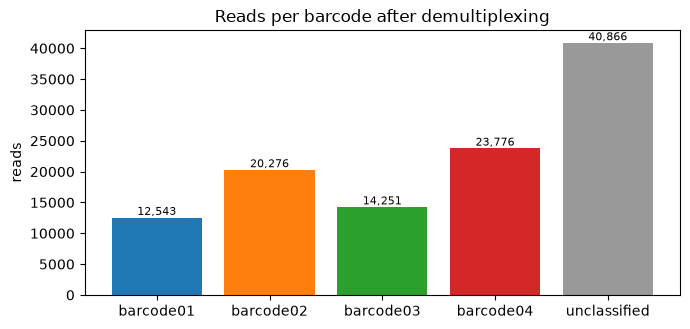

In [99]:
# Reads per barcode after demultiplexing (plus the unclassified reads)
import glob, os, subprocess
import matplotlib.pyplot as plt

counts = {}
for fq in sorted(glob.glob("reads/barcode0[1-4].fastq")):
    n = int(subprocess.run(["wc","-l",fq], capture_output=True, text=True).stdout.split()[0]) // 4
    counts[os.path.basename(fq).replace(".fastq","")] = n
unclassified = 40866   # reads with no detected barcode (from the demux summary; not shown above)

for bc, n in counts.items():
    print(f"{bc}: {n:,} reads")
print(f"unclassified: {unclassified:,} reads")

labels = list(counts) + ["unclassified"]
vals   = list(counts.values()) + [unclassified]
colors = [plt.cm.tab10(i) for i in range(len(counts))] + ["0.6"]
plt.figure(figsize=(7, 3.4))
bars = plt.bar(labels, vals, color=colors)
plt.bar_label(bars, fmt="{:,.0f}", fontsize=8)
plt.ylabel("reads"); plt.title("Reads per barcode after demultiplexing")
plt.tight_layout(); plt.savefig("analysis/demux_read_counts.png", dpi=130); plt.show()

A large fraction of reads is typically **unclassified** with rapid barcoding (the barcode sits
on only one end and is easily missed on short or low-quality reads) - in this run about a third.
That is normal, and a good reminder that demultiplexing is never perfect. We continue with the
four well-populated barcodes.

### Phred quality scores

Each base in a FASTQ has a **Phred quality score** `Q` estimating the probability `P` that the
base call is **wrong**:

$$Q = -10\cdot\log_{10}(P) \qquad\Longleftrightarrow\qquad P = 10^{-Q/10}$$

So Q10 &asymp; 90% correct, Q20 &asymp; 99%, Q30 &asymp; 99.9%. In the FASTQ, line 4 stores one
**ASCII character** per base (**Phred+33** encoding):

```
  ASCII:  !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRS
          |         |         |         |         |         |
  Q:      0         10        20        30        40        50
```

Dorado's neural network emits a confidence for every base; that becomes the Q score written next
to it. The model comparison above summarised exactly these per-base scores.

### Quality-control pipeline

Before mapping we clean the reads. Three standard steps:

```
   raw reads --> [1] NanoPlot (look)  -->  [2] fastplong (filter)  -->  [3] NanoComp (before vs after)
```

NanoPlot summarises the raw reads, **fastplong** filters them, and NanoComp shows the effect.
We demonstrate on one strain; the same recipe applies to all four.

#### QC1 - NanoPlot: look at the raw reads

In [100]:
! NanoPlot --fastq reads/barcode04.fastq -o qc/bc04_raw --prefix bc04_raw_ --loglength -t 4 2>/dev/null
! ls qc/bc04_raw/*.png | head

qc/bc04_raw/bc04_raw_LengthvsQualityScatterPlot_dot.png
qc/bc04_raw/bc04_raw_LengthvsQualityScatterPlot_kde.png
qc/bc04_raw/bc04_raw_LengthvsQualityScatterPlot_loglength_dot.png
qc/bc04_raw/bc04_raw_LengthvsQualityScatterPlot_loglength_kde.png
qc/bc04_raw/bc04_raw_Non_weightedHistogramReadlength.png
qc/bc04_raw/bc04_raw_Non_weightedLogTransformed_HistogramReadlength.png
qc/bc04_raw/bc04_raw_WeightedHistogramReadlength.png
qc/bc04_raw/bc04_raw_WeightedLogTransformed_HistogramReadlength.png
qc/bc04_raw/bc04_raw_Yield_By_Length.png


In [101]:
from IPython.display import IFrame
IFrame("qc/bc04_raw/bc04_raw_LengthvsQualityScatterPlot_loglength_kde.html", width="100%", height=600)

#### QC2 - fastplong: filter the reads

This is a **rapid-barcoding** run, which produces a wide spread of read lengths including many
**short** reads. We apply a gentle clean-up to drop obvious junk, keep the useful reads:

- `-l 500` drop short fragments (< 500 bp) that may map poorly; keep everything longer. No upper limit.
- `-m 10` a light quality floor (meaning Phred Q &ge; 10), which removes the lowest quality reads.
- `-A` disable adapter trimming - Dorado already removed the sequencing adapter and barcode.

In [102]:
# Filter all four barcodes with fastplong (loop over samples.tsv)
import pandas as pd, subprocess, os
samples = pd.read_csv("samples.tsv", sep="\t")
os.makedirs("qc", exist_ok=True)
for _, r in samples.iterrows():
    raw = f"reads/{r['barcode']}.fastq"
    clean = f"reads/{r['barcode']}.clean.fastq"
    subprocess.run(["fastplong","-i",raw,"-o",clean,"-l","500","-m","10","-A",
                    "-w","8","--html",f"qc/{r['barcode']}.fastplong.html",
                    "--json",f"qc/{r['barcode']}.fastplong.json"],
                   capture_output=True)
    raw_n  = int(subprocess.run(["wc","-l",raw],  capture_output=True, text=True).stdout.split()[0])//4
    cln_n  = int(subprocess.run(["wc","-l",clean],capture_output=True, text=True).stdout.split()[0])//4
    print(f"{r['strain']:35s} {raw_n:>7,} -> {cln_n:>7,} reads kept ({100*cln_n/raw_n:.0f}%)")

Bacillus subtilis 168                12,543 ->   4,378 reads kept (35%)
Escherichia coli O157:H7 Sakai       20,276 ->   7,686 reads kept (38%)
Lacticaseibacillus casei ATCC 393    14,251 ->   3,567 reads kept (25%)
Escherichia coli DH5alpha (K-12)     23,776 ->  11,947 reads kept (50%)


#### QC3 - NanoComp: compare before vs after (one strain)

In [103]:
! NanoComp --fastq reads/barcode04.fastq reads/barcode04.clean.fastq \
           --names raw clean -o qc/bc04_rawvsclean --prefix bc04_ -t 4 2>/dev/null
from IPython.display import IFrame
IFrame("qc/bc04_rawvsclean/bc04_NanoComp_quals_violin.html", width="100%", height=600)

### Reference genomes

To make sense of the reads we map them to **reference genomes** - finished sequences for each
species, downloaded from NCBI. Notice the **gradient of relatedness**, which is the heart of the
comparison:

| Strain | Genome size | GC% | rrn operons | relationship |
|---|--:|--:|--:|---|
| *L. casei* ATCC 393 | 3.0 Mb | 48% | 5 | different genus |
| *B. subtilis* 168 | 4.2 Mb | 44% | 10 | different genus |
| *E. coli* DH5&alpha; (K-12) | 4.6 Mb | 51% | 7 | *E. coli* lab strain |
| *E. coli* O157 (Sakai) | 5.5 Mb | 51% | 7 | can be virulent and pathogenic |

We download each genome from NCBI with Biopython (Entrez). The *E. coli* O157 download includes
its two **plasmids** - extra DNA molecules separate from the chromosome (we return to these later).

In [104]:
# Download the reference genomes from NCBI (skips files already present)
import os
from Bio import Entrez, SeqIO
Entrez.email = "toddblev@gmail.com"   # NCBI asks for an email

REFS = {
    "reference_seqs/ref_lcasei_ATCC393.fna":   "AP012544.1,AP012545.1,AP012546.1",
    "reference_seqs/ref_bsubtilis_168.fna":    "NC_000964.3",
    "reference_seqs/ref_ecoli_K12_MG1655.fna": "NC_000913.3",
    "reference_seqs/ref_ecoli_O157_Sakai.fna": "NC_002695.2,NC_002128.1,NC_002127.1",
}
os.makedirs("reference_seqs", exist_ok=True)
for path, acc in REFS.items():
    if os.path.exists(path):
        print(f"✓ {path}")
        continue
    with Entrez.efetch(db="nucleotide", id=acc, rettype="fasta", retmode="text") as h:
        open(path, "w").write(h.read())
    print(f"↓ {path}")

✓ reference_seqs/ref_lcasei_ATCC393.fna
✓ reference_seqs/ref_bsubtilis_168.fna
✓ reference_seqs/ref_ecoli_K12_MG1655.fna
✓ reference_seqs/ref_ecoli_O157_Sakai.fna


In [105]:
# A FASTA can hold several sequences (chromosome + plasmids). Summarise one reference:
! python reference_seqs/read_fasta_bio.py reference_seqs/ref_ecoli_O157_Sakai.fna

NC_002695.2, length 5498578 nt
NC_002128.1, length 92721 nt
NC_002127.1, length 3306 nt
---------------------------
Total length parsed: 5594605 nt


### Mapping reads with minimap2

[minimap2](https://github.com/lh3/minimap2) is the standard aligner for long, error-prone ONT
reads. For each read it finds where it best fits on a reference and writes the alignment in
**SAM/BAM**. We use the `-ax map-ont` preset (tuned for ONT), `--secondary=no` (keep one best
location per read), then `samtools sort` + `index`.

Two different things are called an *index*: the **reference index** minimap2 builds to place
reads, and the **BAM index** (`.bai`) `samtools` builds so tools can jump to a region of a sorted
BAM. We always **sort then index**.

In [106]:
! minimap2 --help 2>&1 | head -5

Usage: minimap2 [options] <target.fa>|<target.idx> [query.fa] [...]
Options:
  Indexing:
    -H           use homopolymer-compressed k-mer (preferrable for PacBio)
    -k INT       k-mer size (no larger than 28) [15]


### Map each strain to its genome

Now map each strain's cleaned reads to its reference, and check how well they map and how deep
the coverage is.

In [107]:
import pandas as pd, subprocess, os
samples = pd.read_csv("samples.tsv", sep="\t")
os.makedirs("mapping_bam", exist_ok=True)
for _, r in samples.iterrows():
    clean = f"reads/{r['barcode']}.clean.fastq"
    bam = f"mapping_bam/{r['key']}.bam"
    mm = subprocess.Popen(["minimap2","-ax","map-ont","--secondary=no","-t","8",
                           r["reference"], clean], stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
    subprocess.run(["samtools","sort","-o",bam,"-"], stdin=mm.stdout); mm.wait()
    subprocess.run(["samtools","index",bam])
    cov = subprocess.run(["samtools","coverage",bam], capture_output=True, text=True).stdout
    # mean depth of the longest contig (the chromosome)
    rows = [l.split("\t") for l in cov.strip().splitlines()[1:]]
    chrom = max(rows, key=lambda x: int(x[2]))
    print(f"{r['strain']:35s} chromosome mean depth ~{float(chrom[6]):.1f}x")

Bacillus subtilis 168               chromosome mean depth ~4.3x
Escherichia coli O157:H7 Sakai      chromosome mean depth ~6.9x
Lacticaseibacillus casei ATCC 393   chromosome mean depth ~2.2x
Escherichia coli DH5alpha (K-12)    chromosome mean depth ~14.7x


### Confirming that the bacterial strains were correctly bar-coded as assigned: cross-mapping

Here we map **every barcode against every reference** and record the percentage that maps. The result is very informative:

- each barcode's reads should map overwhelmingly to **one** genome (the bright diagonal) - that is how we
  assigned barcodes to strains;
- *L. casei* and *B. subtilis* map **only** to themselves (different genera);
- the two *E. coli* cross-map to **both** *E. coli* references, as expected. "% mapped" alone cannot separate strains of one species;
- **O157 reads map worse to DH5&alpha; (wrong ref) than to O157 (correct ref)**. This lower % in overall mapping is because of reads representing the extra genomic DNA in O157 (~0.9 Mb of prophage and other content) that have nowhere to map in the smaller DH5&alpha; reference genome.

mapping each barcode against each reference ...
  Bacillus subtilis 168               -> Bacillus subtilis 168   (79.6   0.6   1.0   0.6)
  Escherichia coli O157:H7 Sakai      -> Escherichia coli O157:H7 Sakai   ( 0.5  78.9   0.4  62.0)
  Lacticaseibacillus casei ATCC 393   -> Lacticaseibacillus casei ATCC 393   ( 0.6   0.3  76.9   0.3)
  Escherichia coli DH5alpha (K-12)    -> Escherichia coli DH5alpha (K-12)   ( 1.2  78.8   1.0  81.9)
-> analysis/cross_mapping_matrix_raw.png


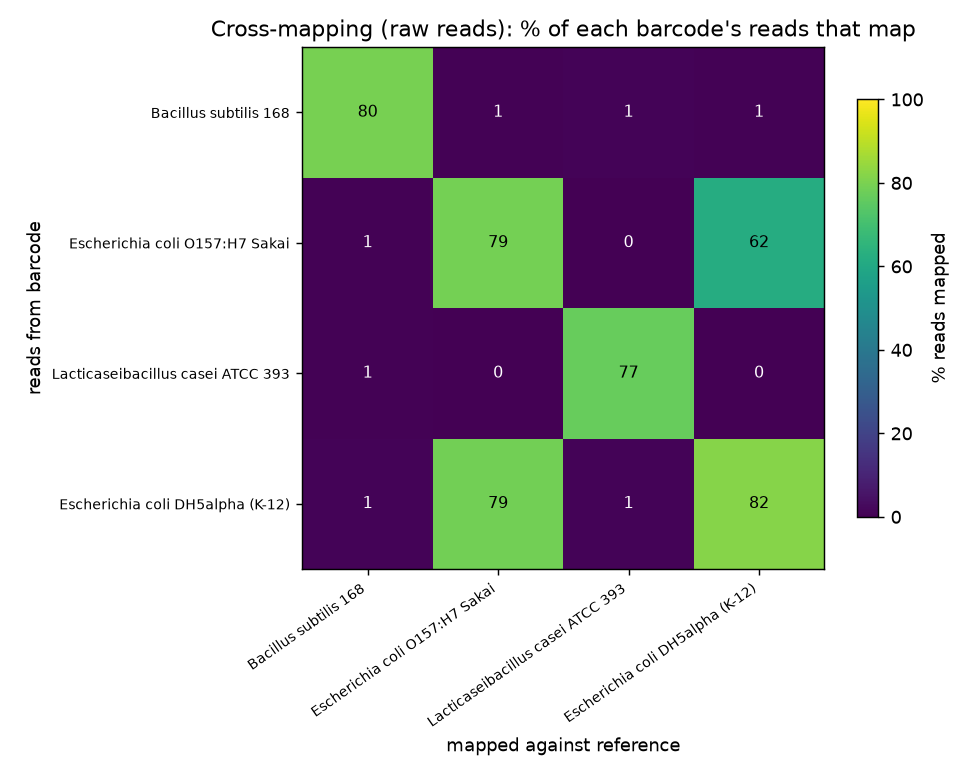

In [108]:
! python analysis/cross_mapping_matrix.py --reads-dir reads --suffix .fastq \
        --out analysis/cross_mapping_matrix_raw.png \
        --title "Cross-mapping (raw reads): % of each barcode's reads that map"
from IPython.display import Image
Image("analysis/cross_mapping_matrix_raw.png")

#### The same comparison on the QC-cleaned reads

The matrix above ran on the **raw** reads, so even the correct (diagonal) reference tops out near
**~80%** - the rest are short (<~100 bp) reads that can't be placed. Re-running on the
**fastplong-cleaned** reads (`*.clean.fastq`) drops that short-read tail: each barcode now maps to
its own genome at **~98-99%**, and the pattern is identical but sharper. The two *E. coli* still
light up against **both** *E. coli* references (DH5&alpha; reads &rarr; O157 ref ~96%, O157 reads
&rarr; DH5&alpha; ref ~83% - the latter lower because O157 carries ~0.9 Mb of extra prophage DNA
absent from the K-12 reference). So QC strongly influences the absolute mapping rate.

mapping each barcode against each reference ...
  Bacillus subtilis 168               -> Bacillus subtilis 168   (98.0   1.5   2.2   1.5)
  Escherichia coli O157:H7 Sakai      -> Escherichia coli O157:H7 Sakai   ( 1.1  98.6   0.8  83.3)
  Lacticaseibacillus casei ATCC 393   -> Lacticaseibacillus casei ATCC 393   ( 1.3   0.8  99.4   0.8)
  Escherichia coli DH5alpha (K-12)    -> Escherichia coli DH5alpha (K-12)   ( 2.0  96.5   1.7  98.4)
-> analysis/cross_mapping_matrix_clean.png


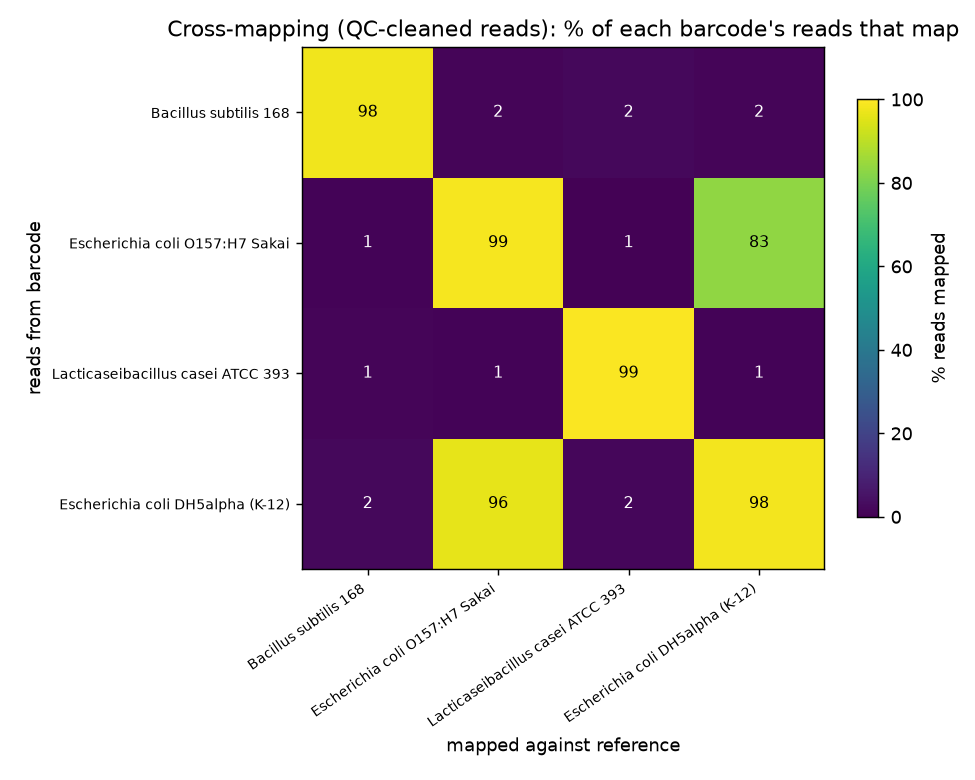

In [109]:
# Cross-mapping repeated on the QC-cleaned reads (.clean.fastq from the fastplong step)
! python analysis/cross_mapping_matrix.py --reads-dir reads --suffix .clean.fastq \
        --out analysis/cross_mapping_matrix_clean.png \
        --title "Cross-mapping (QC-cleaned reads): % of each barcode's reads that map"
from IPython.display import Image
Image("analysis/cross_mapping_matrix_clean.png")

### One read, several alignment lines (and MAPQ)

A read can produce more than one line in a BAM. The SAM **FLAG** distinguishes them:

| Kind | FLAG bit | Meaning |
|---|---|---|
| primary | - | the single best alignment of the read |
| secondary | `0x100` | an alternative full location (maps about equally well elsewhere) |
| supplementary | `0x800` | a chimeric/split alignment (different parts map to different places) |

To count **distinct reads** we drop secondary+supplementary with `-F 0x900`.

Each alignment also has a **MAPQ** (column 5): the confidence that the read is in the **right
place**. High MAPQ (max 60) = one clear location; MAPQ **0** = the read fits two or more places
equally well. This matters for the **rrn operons**: they are repeated and nearly identical, so a read lying
**entirely inside** one can't be tied to a single copy and gets **MAPQ 0**. But most ONT reads
are long enough to reach the **unique genes flanking** the operon, so they are still placed
confidently - long reads *resolve* the repeats. We see both below on the **DH5&alpha; (K-12)**
reads: first a single read, then a count over an rrn operon where **nearly all reads keep a
confident MAPQ (here 27 of 28); only the one read lying wholly inside the repeat is MAPQ 0**.

In [110]:
# One read (the first) in the DH5alpha (K-12) BAM. -F 0x900 drops secondary/supplementary.
# Columns: 1 name | 2 FLAG | 3 reference | 4 position | 5 MAPQ | 6 CIGAR | ... | 10 sequence
! samtools view -F 0x900 mapping_bam/ecoli_K12.bam | head -n 1

6abe8d74-281b-42ef-bf5e-77e248943153	0	NC_000913.3	1	60	15488S301M1D448M1D102M2D131M1D138M3D18M3D563M1D1076M1D47M1I3M1D6M2D4M2D4M1D665M1I96M3I67M1D1375M1D154M1D262M1I372M1D628M1D3M2D199M1I110M1D10M2D149M1I62M1I758M1I3M2D99M1I131M1D7M2I66M1D20M1D220M3D184M1I969M1I3M1D346M1I54M1I675M2I176M1D625M2I56M1I573M1D108M1D1021M1D1072M1D376M1D566M1I2M1I85M1I97M1I4M1D123M1I564M1D227M1I371M3D293M1D25M6I5M1D125M1D43M1I17M1I209M1I220M3I277M1D109M2D31M	*	0	0	...	,212112,++''''&('&$$$$%%%%&))*+/?EIGFFFSB?=;9530*((%%&9<=@?<=<<DHISSSNIKSSSSSSKOSPMSSSSSSSSSSSQSSCBAAC?;:>@00028899;;;=DBDDCSKHIKLLJLSSSIJSSSSNSEBA;=D;9:866666@;BBBFDCGGFFMMIKKSS?>>>>954/+)&%%%%&01H1ILSSSSSLMJKJJGKJJQSJKSSMGISSSSSSHQKHDED?>?;<;;;<<4444CBSSSSSSSSSSSHKSSMLI?>>??LOSSSSSSSSSQPSNSSISSOSJSC<>;;;:;????>>??QIGSSSIA?C8NSSSSMSSSNSSSSSJQSSSSSNIIKSSRKIGJMHHKSSSSSSSQSNSSSSOSLIRSQLSKSLSSSFIKPJMS===00111;;00000ONSSSSSSQSSSSSSSMSPSSSSSSSSRSSJOLJSSSSSSSSOOLSSSSSPSQNNSLSSSSKKHKSSIFDEA@ABEHOHPISOSSSSSSOSSSSSSSKHSSSSSLJLLMSNSSLI@@??555569120'&''&&

In [115]:
# Now reads over an rrn operon (rrnH, ~0.22 Mb on NC_000913.3). The seven operons are
# near-identical, so most reads here can't be placed to one copy. Count all reads over the
# operon, then only those that keep MAPQ >= 1 - the drop is due to MAPQ-0 (ambiguous) reads:
! samtools view -c mapping_bam/ecoli_K12.bam NC_000913.3:223771-228870
! samtools view -c -q 1 mapping_bam/ecoli_K12.bam NC_000913.3:223771-228870

28
27


In [116]:
# distinct mapped reads (primary only) for each strain
# Here we add the -c flag to count these primary mappings for each bacterial genome
! echo 'B. subtilis primary-mapped reads:'; samtools view -c -F 0x900 mapping_bam/bsubtilis.bam
! echo 'E. coli O157:H7 primary-mapped reads:'; samtools view -c -F 0x900 mapping_bam/ecoli_O157.bam
! echo 'L. casei primary-mapped reads:'; samtools view -c -F 0x900 mapping_bam/lcasei.bam
! echo 'E. coli DH5Alpha primary-mapped reads:'; samtools view -c -F 0x900 mapping_bam/ecoli_K12.bam

B. subtilis primary-mapped reads:
4378
E. coli O157:H7 primary-mapped reads:
7686
L. casei primary-mapped reads:
3567
E. coli DH5Alpha primary-mapped reads:
11947


## rrn operon copy number from coverage depth

Bacteria carry several copies of the **ribosomal RNA (rrn) operon** (the 16S-23S-5S genes).
Fast-growing bacteria tend to have **more** copies. Our four strains have known counts:
*L. casei* **5**, *E. coli* **7**, *B. subtilis* **10**. Can we recover these from the reads?

**First idea (does not work):** look for tall coverage spikes at the operons on the genome.
Let's try it.

  located 7 ecoli_K12_rrn_operon.fna copies on NC_000913.3
NC_000913.3: 4642 windows, median depth 15.0x  ->  analysis/coverage_ecoli_K12.png


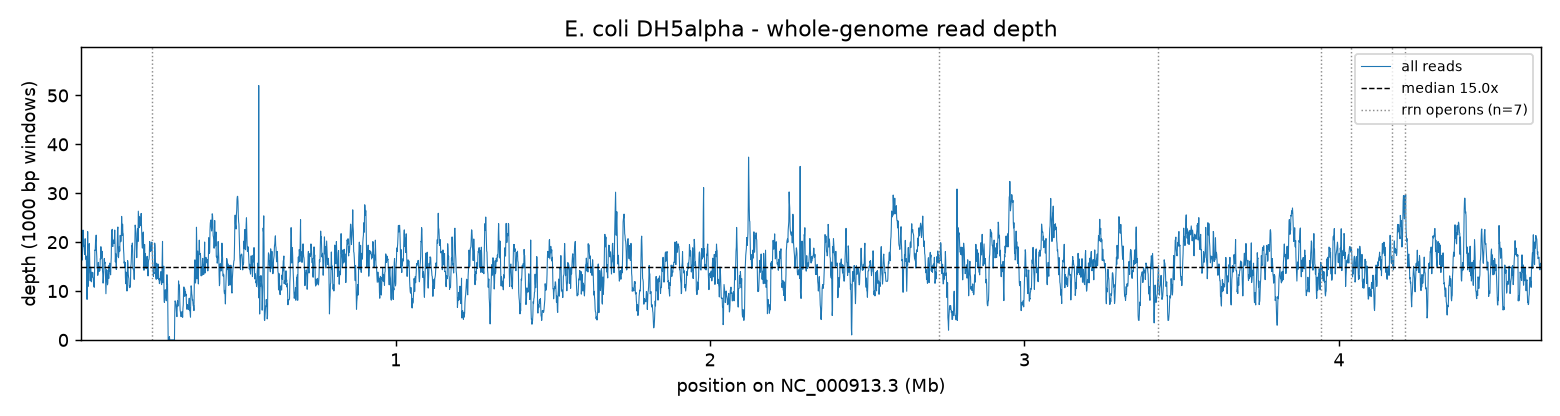

In [117]:
# Whole-genome coverage for E. coli DH5alpha (our deepest sample)
# Grey dotted lines mark the seven rrn operons, located by aligning one operon back to the genome
! python analysis/coverage_track.py mapping_bam/ecoli_K12.bam analysis/coverage_ecoli_K12.png \
        --title "E. coli DH5alpha - whole-genome read depth" \
        --operon reference_seqs/operons/ecoli_K12_rrn_operon.fna \
        --ref reference_seqs/ref_ecoli_K12_MG1655.fna
from IPython.display import Image
Image("analysis/coverage_ecoli_K12.png")

The coverage is **flat** - no towering peaks at the operons (you might have expected ~7-fold
spikes for the seven copies). Why? ONT reads are long enough to span an operon **plus** its unique
neighbouring genes, so most operon reads are placed at their **correct** copy, spreading evenly.
Reads that fall entirely inside the conserved core are ambiguous (MAPQ 0) and get scattered across
the copies. The **grey dotted lines** mark the seven rrn operons (one near 0.22 Mb, one near 2.73 Mb, and
five clustered between ~3.4 and 4.2 Mb, by the replication origin) - and the depth at each just sits near the median, with no spike. So copy number is **not** readable as spike height.

**What works:** map the reads to **one single operon** instead of the whole genome.
Now reads from *all* the genomic copies have only one place to go, so they **pile up** to roughly
(copy number) &times; the normal single-copy depth:

$$\text{copy number} \;\approx\; \frac{\text{depth on one operon}}{\text{genome-median depth}}$$

== rrn operon copy number: Bacillus subtilis 168 ==
  genome-median depth (single copy) :   4.0x   (NC_000964.3)
  single-operon pile-up depth       :  31.5x   (operon 5001 bp)
  estimated copy number  = 31.5 / 4.0 = 7.9   (expected 10)

== rrn operon copy number: Escherichia coli O157:H7 Sakai ==
  genome-median depth (single copy) :   6.8x   (NC_002695.2)
  single-operon pile-up depth       :  28.8x   (operon 5095 bp)
  estimated copy number  = 28.8 / 6.8 = 4.2   (expected 7)

== rrn operon copy number: Lacticaseibacillus casei ATCC 393 ==
  genome-median depth (single copy) :   2.0x   (AP012544.1)
  single-operon pile-up depth       :  11.2x   (operon 5021 bp)
  estimated copy number  = 11.2 / 2.0 = 5.6   (expected 5)

== rrn operon copy number: Escherichia coli DH5alpha (K-12) ==
  genome-median depth (single copy) :  15.0x   (NC_000913.3)
  single-operon pile-up depth       : 122.0x   (operon 5105 bp)
  estimated copy number  = 122.0 / 15.0 = 8.2   (expected 7)



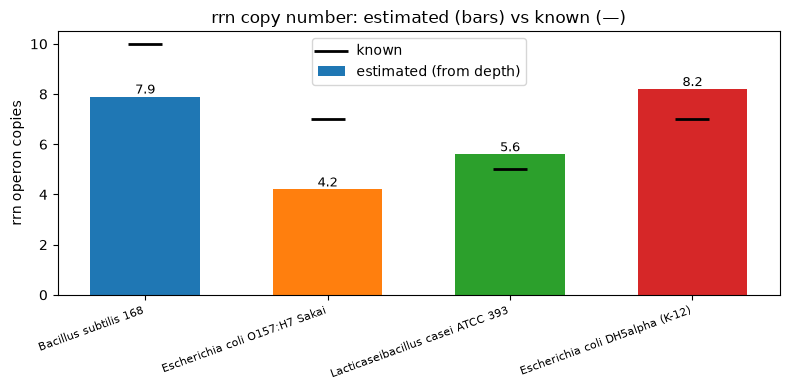

In [118]:
# Estimate rrn copy number for every strain (collapsed-reference method)
import pandas as pd, subprocess, numpy as np
import matplotlib.pyplot as plt
samples = pd.read_csv("samples.tsv", sep="\t")

est, exp, labs = [], [], []
for _, r in samples.iterrows():
    out = subprocess.run(["python","analysis/rrn_copy_number.py",
                          "--fastq", f"reads/{r['barcode']}.clean.fastq",
                          "--operon", r["operon"],
                          "--full-bam", f"mapping_bam/{r['key']}.bam",
                          "--label", r["strain"], "--expected", str(r["rrn_copies"])],
                         capture_output=True, text=True)
    print(out.stdout)
    for line in out.stdout.splitlines():
        if "estimated copy number" in line:
            est.append(float(line.split("=")[-1].split("(")[0].strip()))
    exp.append(int(r["rrn_copies"])); labs.append(r["strain"])

x = np.arange(len(labs))
plt.figure(figsize=(8, 4))
bars = plt.bar(x, est, width=0.6, color=[plt.cm.tab10(i) for i in x], label="estimated (from depth)")
plt.bar_label(bars, fmt="{:.1f}", fontsize=9)
plt.scatter(x, exp, color="black", marker="_", s=600, linewidths=2, zorder=3, label="known")
plt.xticks(x, labs, rotation=20, ha="right", fontsize=8)
plt.ylabel("rrn operon copies"); plt.legend()
plt.title("rrn copy number: estimated (bars) vs known (—)")
plt.tight_layout(); plt.savefig("analysis/rrn_copy_number.png", dpi=130); plt.show()

### Reading the result critically

The known counts are *L. casei* **5**, *E. coli* **7** (both DH5&alpha; and O157), and
*B. subtilis* **10**. The estimates come **closest for *L. casei* (5.6 vs 5) and *E. coli*
DH5&alpha; (8.2 vs 7)** - both a little **over** - while *B. subtilis* (7.9 vs 10) and especially
*E. coli* O157 (4.2 vs 7) **under-count**.

Notice that accuracy here does **not** simply track sequencing depth: *L. casei* is our
**shallowest** sample (~2x) yet lands closest to the truth, while O157 - better covered than
*L. casei* - is the furthest off. Depth sets how **noisy** the estimate is; the **direction** of
the error is set by read length and operon similarity.

A depth-based copy number is a quick **estimate**, not an exact count, and several real-world
factors bias it - exactly what to keep in mind whenever you read copy number off coverage:

- **coverage** - most barcodes here are only a few-fold deep, so the estimate is **noisy** (it
  scatters around the truth); deeper samples like DH5&alpha; are steadier, but more depth does not
  by itself remove the systematic biases below;
- **read length** - reads shorter than the ~5 kb operon only partially pile up, lowering the count
  (a major driver of the *B. subtilis* and O157 under-counts);
- **operon heterogeneity** - *E. coli* rrn operons differ in their internal spacer, so not all reads
  from the seven copies map equally to the single reference operon (**O157 under-counts most**).

### Optional #1: plasmids

The *E. coli* O157 reference includes two **plasmids** - pO157 (~92 kb) and pOSAK1 (~3.3 kb) -
separate DNA molecules alongside the chromosome. `samtools coverage` reports the depth on each.
Two things to read from the table:

- **pO157 is present**, at roughly the **same depth as the chromosome** - about one copy per cell
  (large virulence plasmids like pO157 are typically low-copy).
- **pOSAK1 shows essentially no coverage** - it is **not detected** in this isolate's reads. Plasmid
  content varies between strains, and mapping is a quick way to see which plasmids a strain carries.

So depth reports both the **presence/absence** and the **relative copy number** of extra-chromosomal DNA.

In [119]:
! samtools coverage mapping_bam/ecoli_O157.bam

#rname	startpos	endpos	numreads	covbases	coverage	meandepth	meanbaseq	meanmapq
NC_002695.2	1	5498578	7676	5272498	95.8884	6.8566	36.2	57.7
NC_002128.1	1	92721	196	87427	94.2904	7.42929	35.5	59.6
NC_002127.1	1	3306	0	0	0	0	0	0


### Optional #2: de-novo genome assembly

So far we **mapped** reads to known references. You can instead **assemble** a genome from the
reads alone, with [Flye](https://github.com/fenderglass/Flye):

```bash
flye --nano-hq reads/barcode04.clean.fastq --out-dir flye_dh5a --threads 8
```

Assembly is slow and memory-hungry, so we ran it for you on **E. coli DH5&alpha;** - our
deepest-covered sample (~15x). (Contiguity depends strongly on depth: the other strains here have
too little coverage to assemble well, which is why we show only DH5&alpha;.) The pre-computed
result is in `assembly/`.

Flye's `assembly_info.txt` reports each contig's length and **depth**. Two things to notice: the
chromosome assembles into one large multi-Mb contig, and the multi-copy **rrn** region collapses
into a small **circular, high-coverage** contig at several times the chromosomal depth - the
assembler doing the exact "collapse &rarr; multiplied depth" trick we used to count rrn operons.

In [120]:
# Flye's per-contig report for the DH5alpha assembly (pre-computed, shipped in assembly/)
! cat assembly/dh5a_assembly_info.txt

import pandas as pd
ai = pd.read_csv("assembly/dh5a_assembly_info.txt", sep="\t")
L = sorted(ai["length"], reverse=True)
tot = sum(L); half = tot/2; c = 0; n50 = 0
for x in L:
    c += x
    if c >= half:
        n50 = x; break
print(f"\ncontigs {len(L)}, total {tot/1e6:.2f} Mb, largest {L[0]/1e6:.2f} Mb, contig-N50 {n50:,} "
      f"(true DH5alpha genome ~4.64 Mb)")
print("\ncollapsed high-coverage (repeat / rrn) contigs - depth >> chromosome:")
print(ai[ai["cov."] > 28][["#seq_name", "length", "cov.", "circ.", "mult."]].to_string(index=False))

#seq_name	length	cov.	circ.	repeat	mult.	alt_group	graph_path
contig_13	3536846	14	N	N	1	*	13
contig_63	524595	15	N	N	1	*	63
contig_59	224653	15	N	N	1	*	59
contig_7	194295	15	N	N	1	*	7
contig_14	80432	8	N	N	1	*	14
contig_3	44522	12	N	N	1	*	3,-4
contig_18	32600	7	N	Y	1	16	*,18,*
contig_49	32527	5	N	N	1	*	*,49,*
contig_17	28333	3	N	Y	1	16	*,17,*
contig_12	25405	7	N	N	1	*	*,12,*
contig_15	20982	3	N	Y	1	14	*,15,*
contig_2	18937	11	N	N	1	*	2
contig_29	17279	6	N	Y	1	24	*,29,*
contig_42	15835	5	N	Y	1	36	*,42,*
contig_11	15149	5	N	N	1	*	11,-4
contig_27	13053	6	N	Y	1	22	*,27,*
contig_21	13047	3	N	Y	1	18	*,21,*
contig_54	9558	6	N	Y	1	44	*,54,*
contig_64	9486	63	Y	Y	4	*	64
contig_25	8404	3	N	Y	1	20	*,25,*
contig_61	6829	3	N	Y	1	50	*,61,*
contig_65	6737	30	Y	Y	2	*	65
contig_1	4956	3	N	N	1	*	*,1,*
contig_38	3643	5	N	Y	1	32	*,38,*
contig_23	3549	5	N	N	1	*	*,23,*
contig_32	3515	5	N	Y	1	26	*,32,*
contig_33	3071	5	N	Y	5	*	*,33,*
contig_46	2549	4	N	Y	1	38	*,46,*
contig_37	1844	5	N	Y	1	30	*,37,*
contig_4

### Appendix

**What we did:** raw signal (pod5) &rarr; basecalling (Dorado fast/hac/sup) &rarr;
demultiplexing &rarr; QC (NanoPlot / fastplong / NanoComp) &rarr; mapping (minimap2) &rarr;
comparison (cross-mapping) &rarr; rrn copy number from depth &rarr; plasmids &rarr;
(optional) assembly.

**Reference accessions:** *L. casei* ATCC 393 `GCF_000829055.1` (AP012544-46);
*B. subtilis* 168 `NC_000964.3`; *E. coli* K-12 MG1655 `NC_000913.3`;
*E. coli* O157:H7 Sakai `NC_002695.2` + plasmids `NC_002128.1`, `NC_002127.1`.

**License:** &copy; 2026 Todd Blevins, CC BY-NC 4.0.